# Preparando o ambiente

In [15]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier

In [16]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [17]:
"""
 Dicionário do dataset:
 - Age: Idade do funcionário
 - Attrition: Se o funcionário saiu ou não da empresa
 - BusinessTravel: Frequência de viagens a trabalho
 - DailyRate: Valor da diária do funcionário
 - Department: Departamento onde o funcionário trabalha
 - DistanceFromHome: Distância da casa até o trabalho
 - Education: Nível de educação do funcionário {
    1: 'Below College', 2: 'College', 3: 'Bachelor', 4: 'Master', 5: 'Doctor'
    }
 - EducationField: Área de estudo do funcionário
 - EmployeeCount: Contagem de funcionários (sempre 1)
 - EmployeeNumber: Número de identificação do funcionário
 - EnvironmentSatisfaction: Satisfação com o ambiente de trabalho {
    1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'
    }
 - Gender: Gênero do funcionário
 - HourlyRate: Taxa horária do funcionário
 - JobInvolvement: Envolvimento no trabalho {
    1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'
    }
 - JobLevel: Nível do trabalho
 - JobRole: Cargo do funcionário
 - JobSatisfaction: Satisfação com o trabalho {
    1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'
    }
 - MaritalStatus: Estado civil do funcionário
 - MonthlyIncome: Renda mensal do funcionário
 - MonthlyRate: Valor mensal do funcionário
 - NumCompaniesWorked: Número de empresas em que o funcionário trabalhou
 - Over18: Se o funcionário é maior de 18 anos (sempre 'Y')
 - OverTime: Se o funcionário faz horas extras
 - PercentSalaryHike: Percentual de aumento salarial
 - PerformanceRating: Avaliação de desempenho {
    1: 'Low', 2: 'Good', 3: 'Excellent', 4: 'Outstanding'
    }
 - RelationshipSatisfaction: Satisfação com relacionamentos {
    1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'
    }
 - StandardHours: Horas padrão (sempre 80)
 - StockOptionLevel: Nível de opções de ações
 - TotalWorkingYears: Total de anos trabalhados
 - TrainingTimesLastYear: Número de treinamentos no último ano
 - WorkLifeBalance: Equilíbrio entre vida pessoal e profissional {
    1: 'Bad', 2: 'Good', 3: 'Better', 4: 'Best'
    }
 - YearsAtCompany: Anos na empresa
 - YearsInCurrentRole: Anos na função atual
 - YearsSinceLastPromotion: Anos desde a última promoção
 - YearsWithCurrManager: Anos com o gerente atual
"""
df.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# Pré-processamento básico

In [18]:
# Converter 'Attrition' para numérico para ver correlação (Yes=1, No=0)
df['Attrition_Numeric'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# Remover colunas irrelevantes para análise (Sempre constantes)
df = df.drop(['EmployeeCount', 'StandardHours', 'Over18'], axis=1)

# Selecionar apenas colunas numéricas para análise de correlação
df_numeric = df.select_dtypes(include=[np.number])


# Análise superficial

In [19]:
# Dados estatísticos básicos
print(df_numeric.describe())

               Age    DailyRate  DistanceFromHome    Education  \
count  1470.000000  1470.000000       1470.000000  1470.000000   
mean     36.923810   802.485714          9.192517     2.912925   
std       9.135373   403.509100          8.106864     1.024165   
min      18.000000   102.000000          1.000000     1.000000   
25%      30.000000   465.000000          2.000000     2.000000   
50%      36.000000   802.000000          7.000000     3.000000   
75%      43.000000  1157.000000         14.000000     4.000000   
max      60.000000  1499.000000         29.000000     5.000000   

       EmployeeNumber  EnvironmentSatisfaction   HourlyRate  JobInvolvement  \
count     1470.000000              1470.000000  1470.000000     1470.000000   
mean      1024.865306                 2.721769    65.891156        2.729932   
std        602.024335                 1.093082    20.329428        0.711561   
min          1.000000                 1.000000    30.000000        1.000000   
25%       

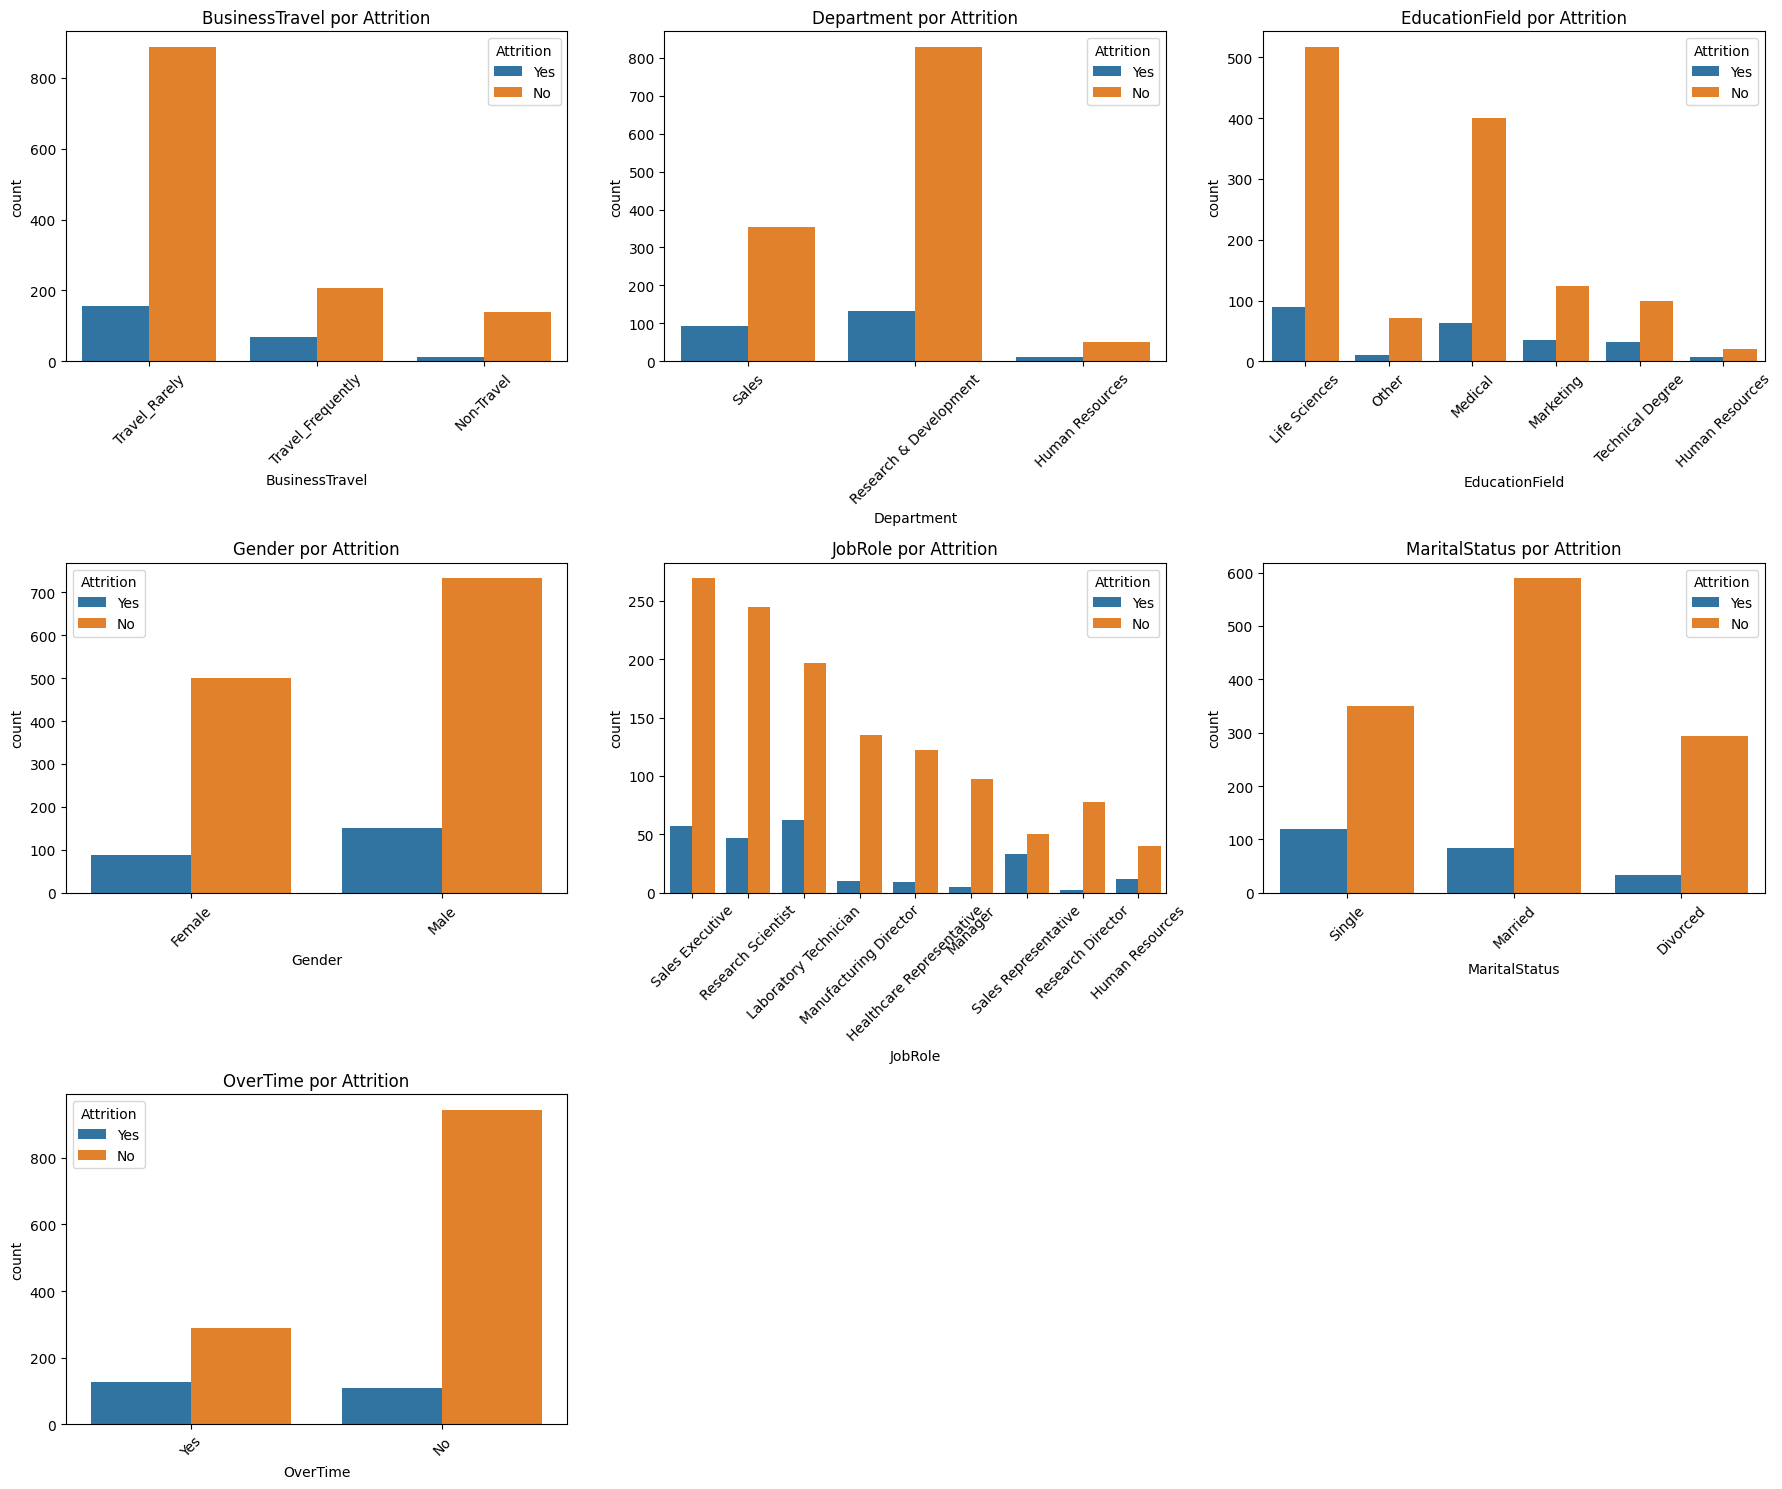

In [56]:
# Análise superficial dos dados qualitativos por Attrition (desgaste de funcionários)
categorical_cols = [
    col for col in df.select_dtypes(include=['object']).columns
    if col != 'Attrition'
]

n_cols = 3  
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    sns.countplot(data=df, x=col, hue='Attrition', ax=ax)
    ax.set_title(f'{col} por Attrition')
    ax.tick_params(axis='x', rotation=45)

for ax in axes[len(categorical_cols):]:
    ax.remove()

plt.tight_layout()
plt.savefig('analise_categoricas_attrition.png')
plt.show()

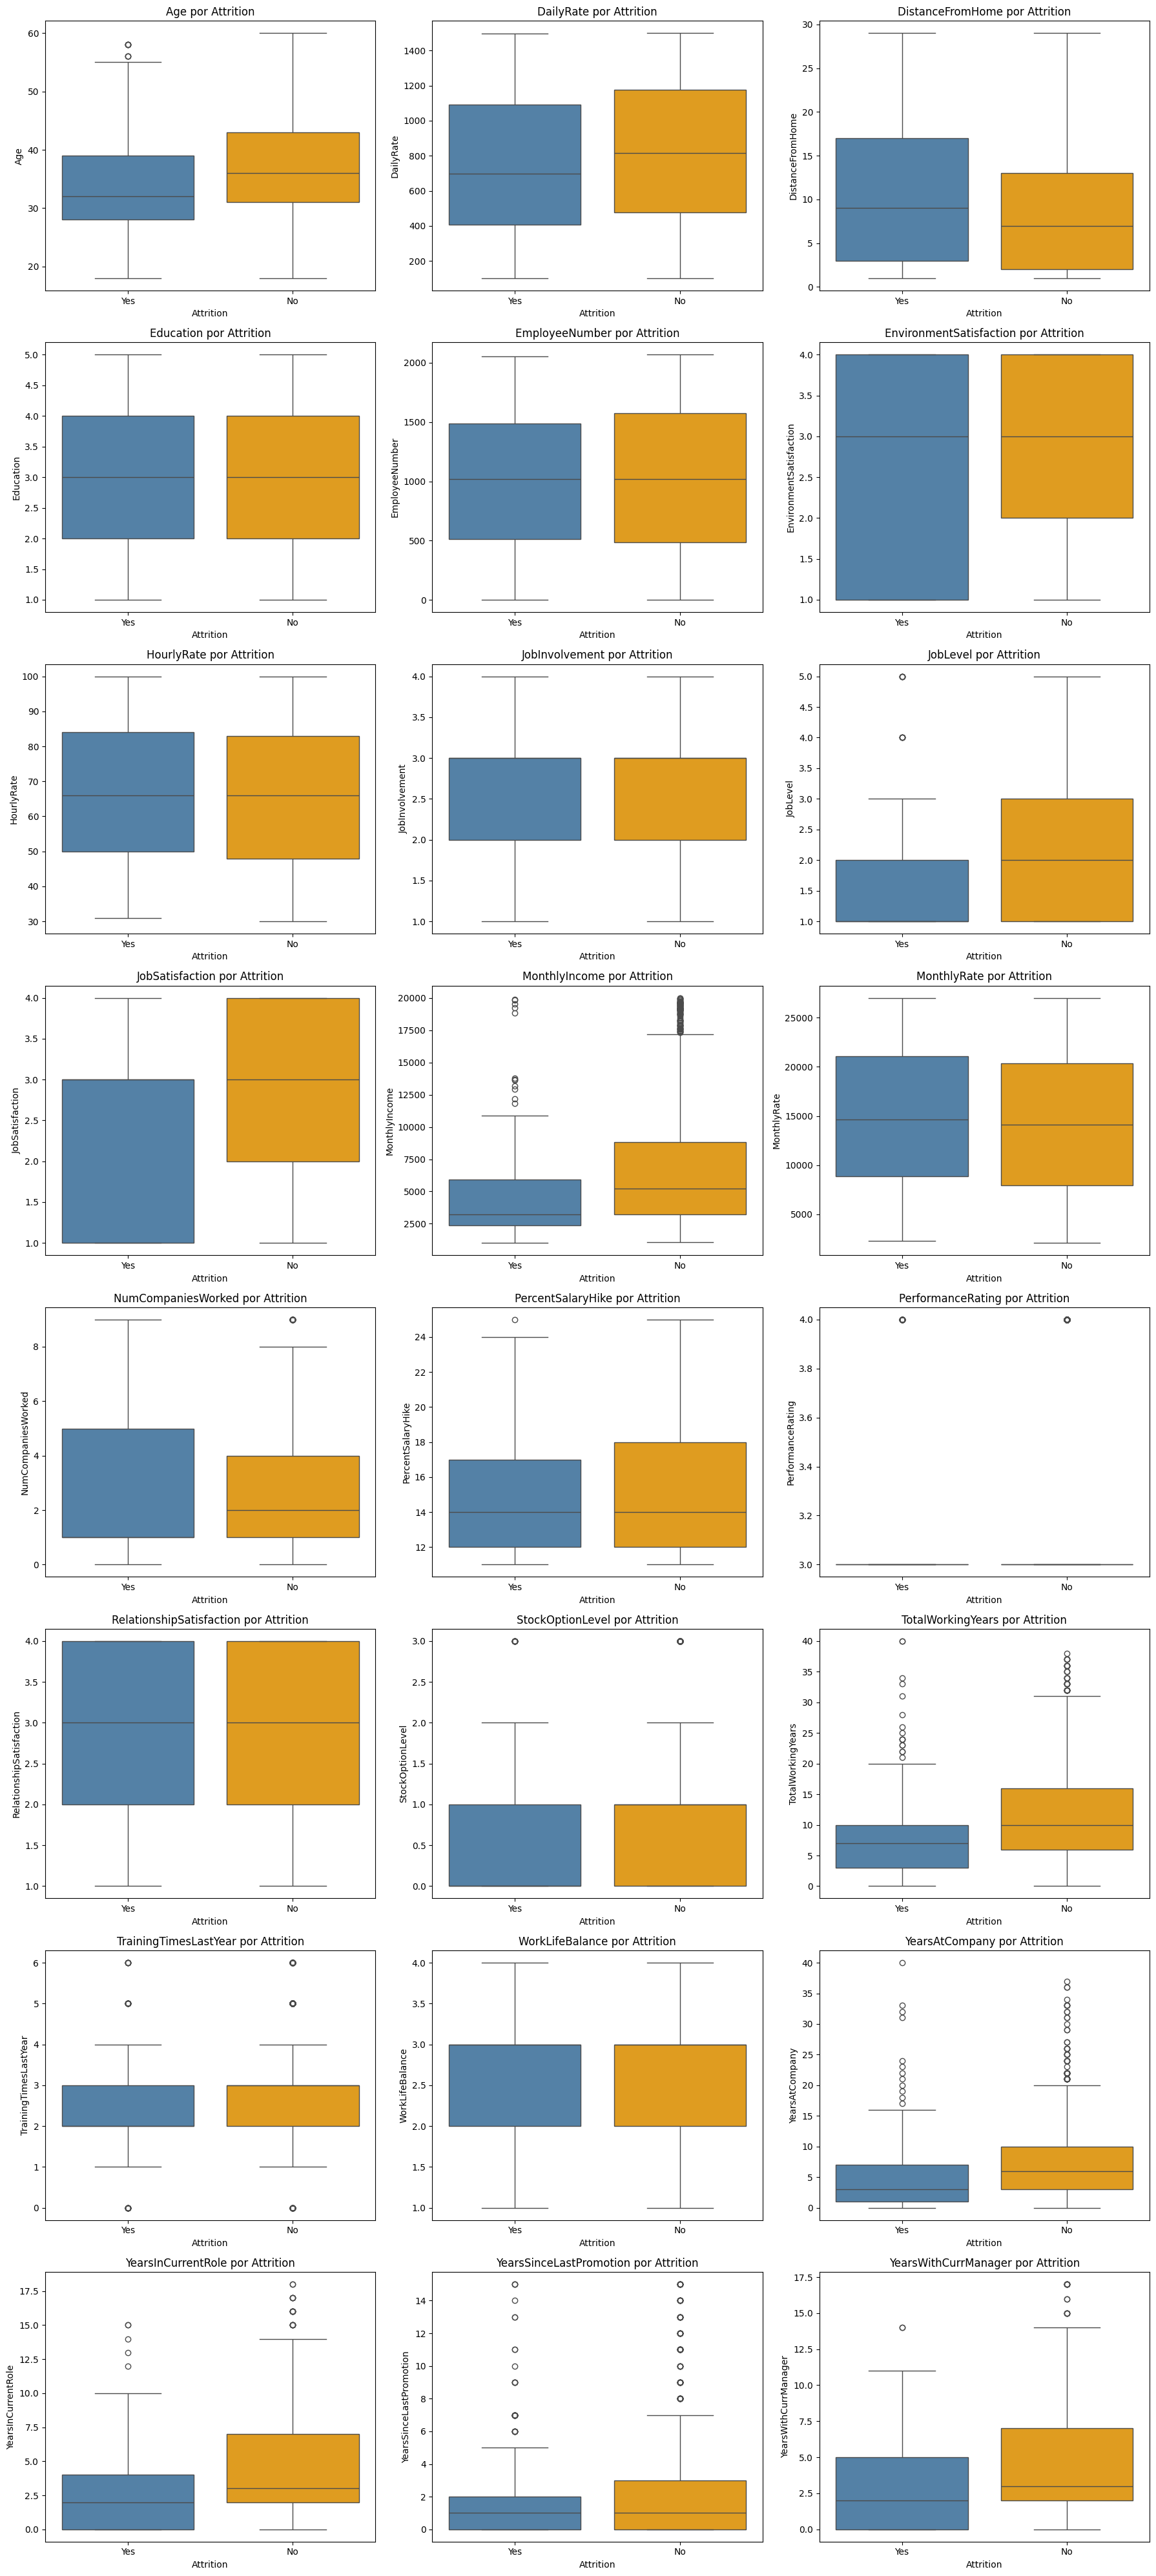

In [55]:
# Análise superficial dos dados numéricos por Attrition (desgaste de funcionários)
numeric_cols = [
    col for col in df_numeric.columns
    if col != 'Attrition_Numeric'
]
palette = {
    'No': 'orange',
    'Yes': 'steelblue'
}

n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(
        data=df,
        x='Attrition',
        y=col,
        hue='Attrition',
        palette=palette,
        legend=False,
        ax=ax
    )
    ax.set_title(f'{col} por Attrition')
for ax in axes[len(numeric_cols):]:
    ax.remove()
plt.tight_layout()
plt.savefig('analise_numerica_attrition.png')
plt.show()

# Análise de correlação


Top 5 correlações com Attrition (desgaste de funcionários):
DistanceFromHome      0.077924
NumCompaniesWorked    0.043494
MonthlyRate           0.015170
PerformanceRating     0.002889
HourlyRate           -0.006846
Name: Attrition_Numeric, dtype: float64


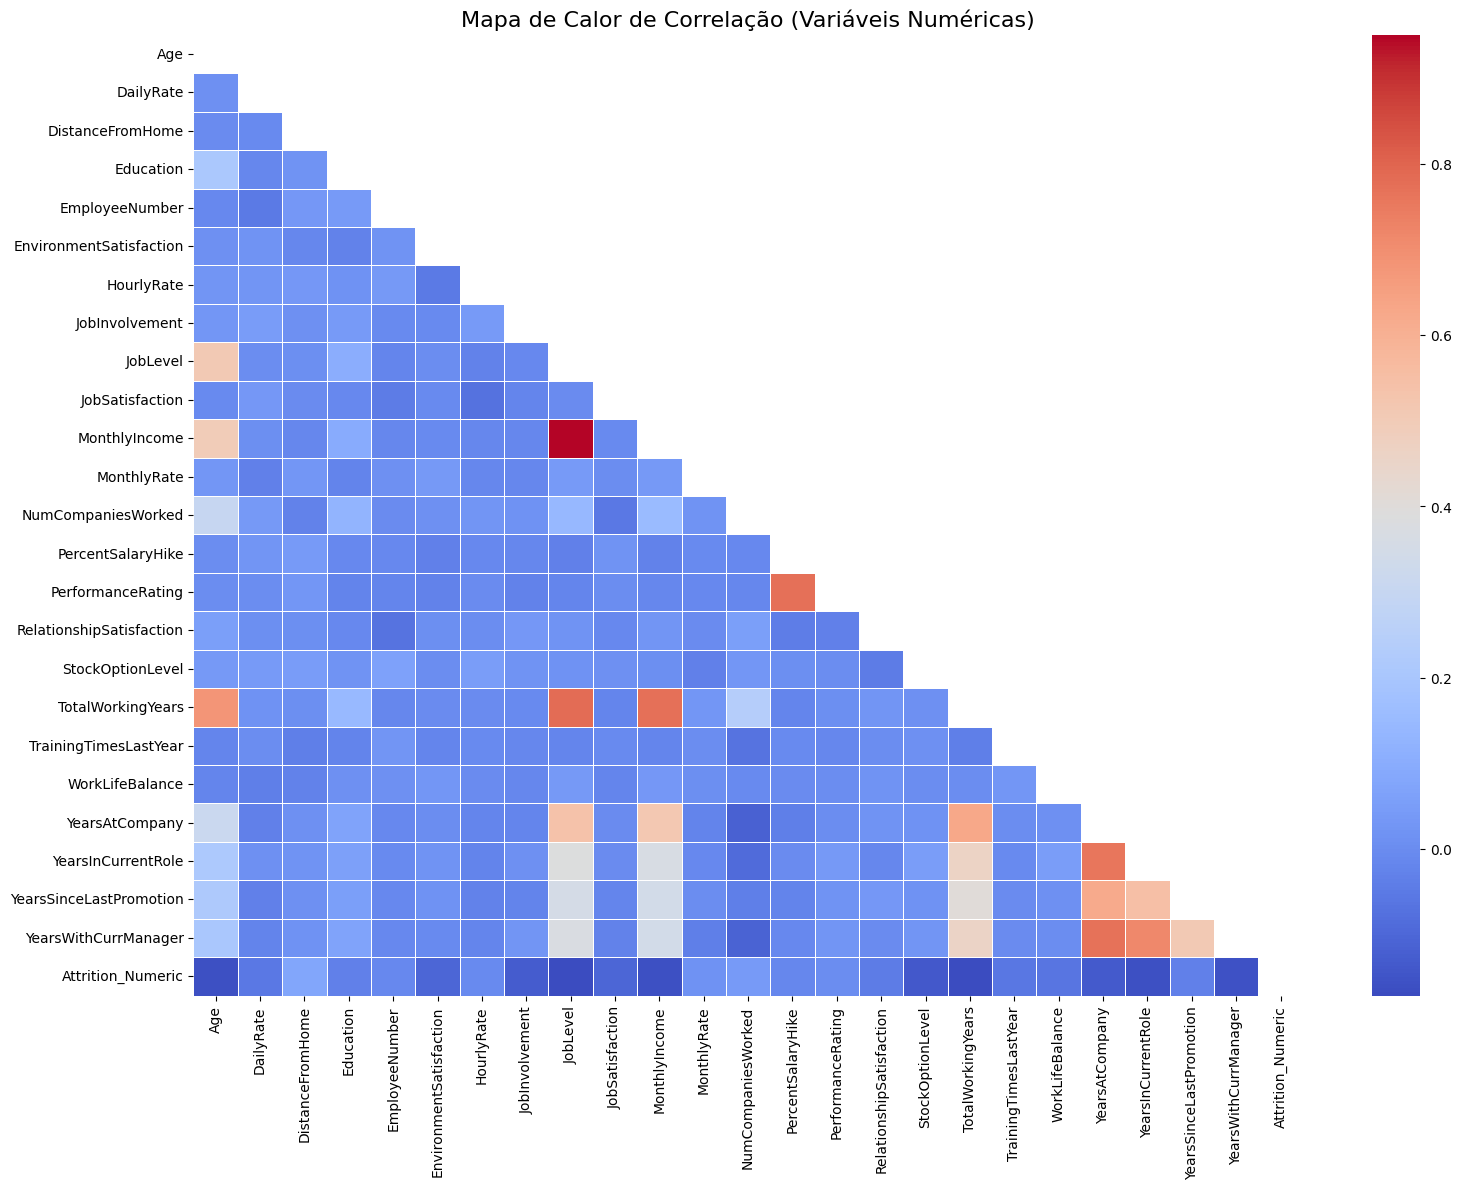

In [54]:
plt.figure(figsize=(16, 12))
corr_matrix = df_numeric.corr()

# Gerar Heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Mascara para triangular superior
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', linewidths=.5)
plt.title('Mapa de Calor de Correlação (Variáveis Numéricas)', fontsize=16)
plt.tight_layout()
plt.savefig('resultado_correlacao.png')

# Mostrando as correlações mais fortes com Attrition
top5 = (
    corr_matrix['Attrition_Numeric']
    .drop('Attrition_Numeric')   # remove autocorrelação (= 1.0)
    .sort_values(ascending=False)
    .head(5)
)
print("\nTop 5 correlações com Attrition (desgaste de funcionários):")
print(top5)

plt.show()

# Clustering (K - Means)

Com 3 perfis

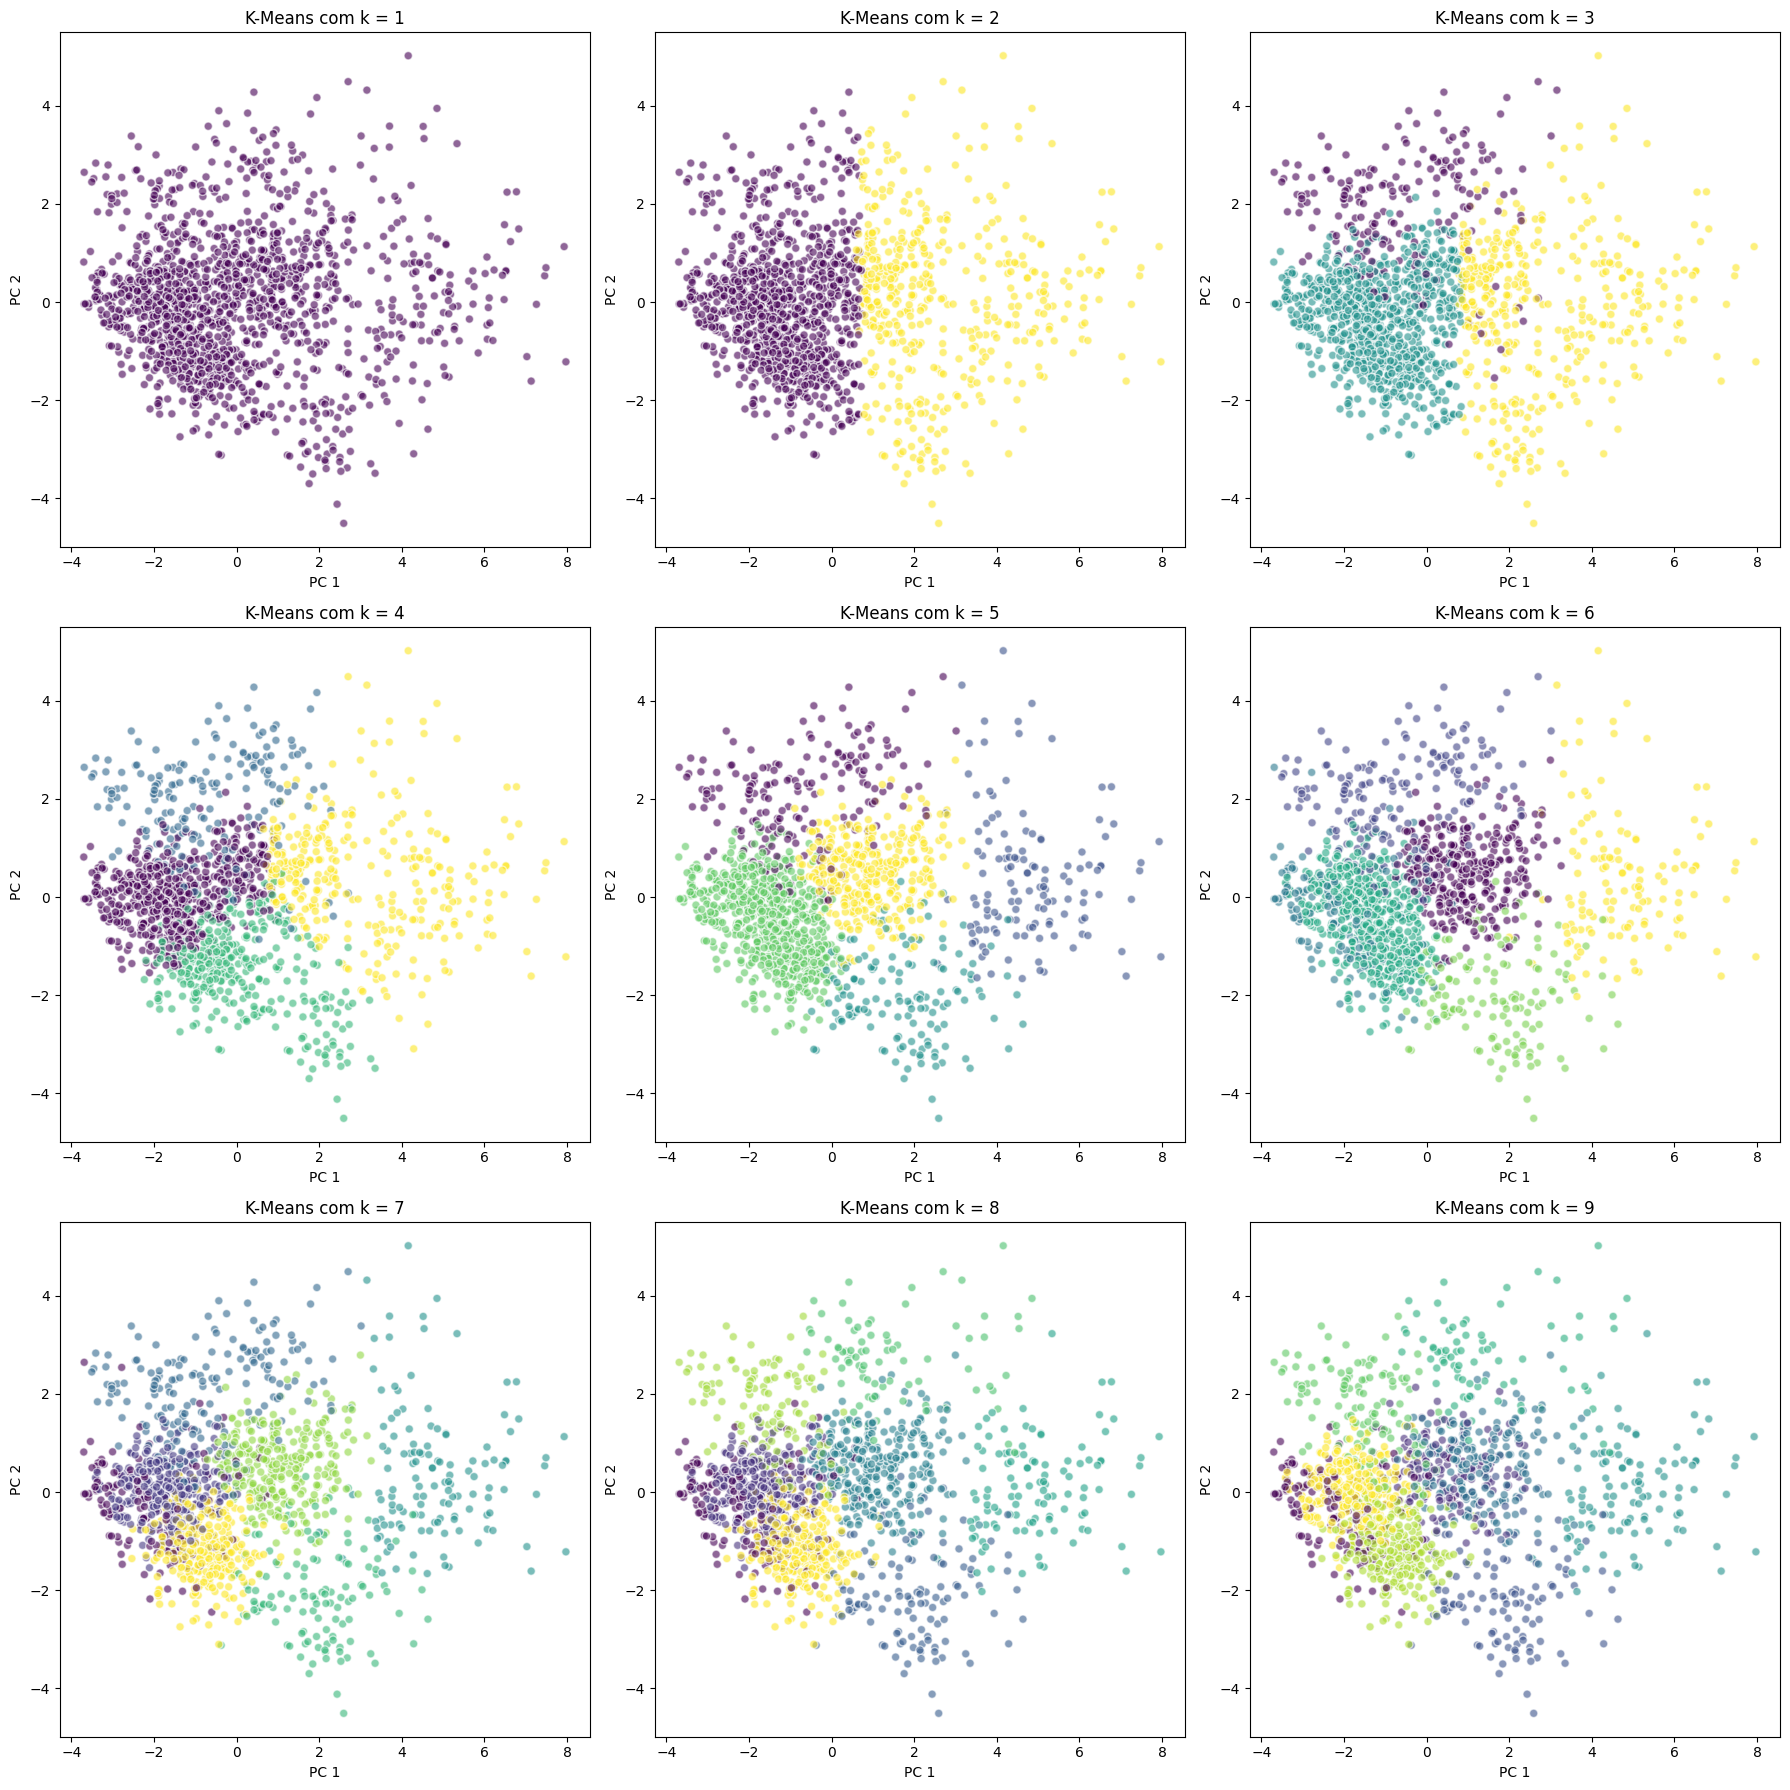

In [53]:
# Padronizar os dados (removendo NaNs)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric.dropna())

# PCA para 2 dimensões (uma vez só)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Criar figura 3x3
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.flatten()

# Loop para k = 1 até 9
for k, ax in zip(range(1, 10), axes):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)

    ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=clusters,
        alpha=0.6,
        edgecolors='w'
    )
    ax.set_title(f'K-Means com k = {k}')
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')

plt.tight_layout()
plt.savefig('clusterings_1-a-9.png')
plt.show()

# Decidindo o número de clusters através do Elbow Method x Silhouette Score

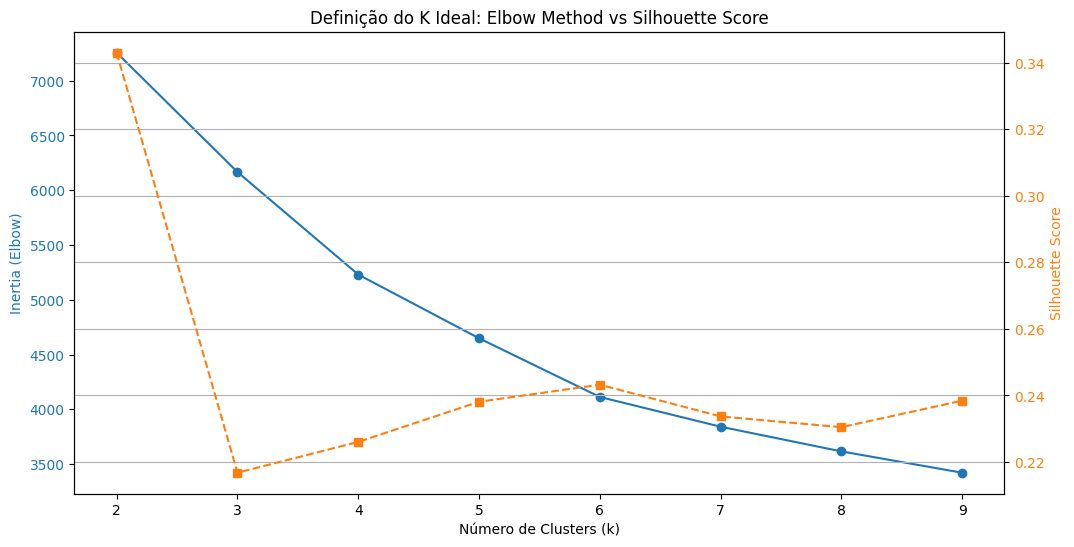

In [52]:
inertia = []
silhouette_scores = []
K_range = range(2, 10) # Testando de 2 a 9 clusters

for k in K_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(X_scaled)
    inertia.append(kmeans_test.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans_test.labels_))

# Plotar os Gráficos de Decisão
fig, ax1 = plt.subplots(figsize=(12, 6))

# Gráfico do Cotovelo (Inertia)
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inertia (Elbow)', color='tab:blue')
ax1.plot(K_range, inertia, 'o-', color='tab:blue', label='Inertia (Elbow)')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Gráfico do Silhouette (Eixo secundário)
ax2 = ax1.twinx() 
ax2.set_ylabel('Silhouette Score', color='tab:orange')
ax2.plot(K_range, silhouette_scores, 's--', color='tab:orange', label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Definição do K Ideal: Elbow Method vs Silhouette Score')
plt.grid(True)
plt.savefig('analise_k_ideal.png')
plt.show()

In [47]:
# Vamos focar nas variáveis que mais definem perfil profissional
cols_cluster = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 
                'YearsAtCompany', 'YearsInCurrentRole', 
                'DistanceFromHome', 'NumCompaniesWorked']

# Filtrar apenas essas colunas para o cluster (remove ruído)
df_cluster_data = df[cols_cluster].dropna()

# Padronizar (StandardScaler é obrigatório para K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster_data)

k_final = 3 
print(f"Executando K-Means final com K={k_final}...")

kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

# Adicionar cluster ao dataframe original (usando o índice para alinhar)
df.loc[df_cluster_data.index, 'Cluster'] = clusters

Executando K-Means final com K=3...


# Análise de influência de variáveis


=== PERFIL MÉDIO DOS CLUSTERS ===
Cluster                     0.0           1.0          2.0
Age                   31.326897     45.708633    40.383298
MonthlyIncome       4394.844138  13203.039568  5787.156317
TotalWorkingYears      6.667586     23.356115    11.250535
YearsAtCompany         5.682759     15.485612     4.019272
YearsInCurrentRole     3.791724      8.230216     2.526767
DistanceFromHome       9.343448      8.992806     9.077088
NumCompaniesWorked     1.051034      2.928058     5.102784
Attrition_Numeric      0.183448      0.068345     0.182013
Contagem             725.000000    278.000000   467.000000


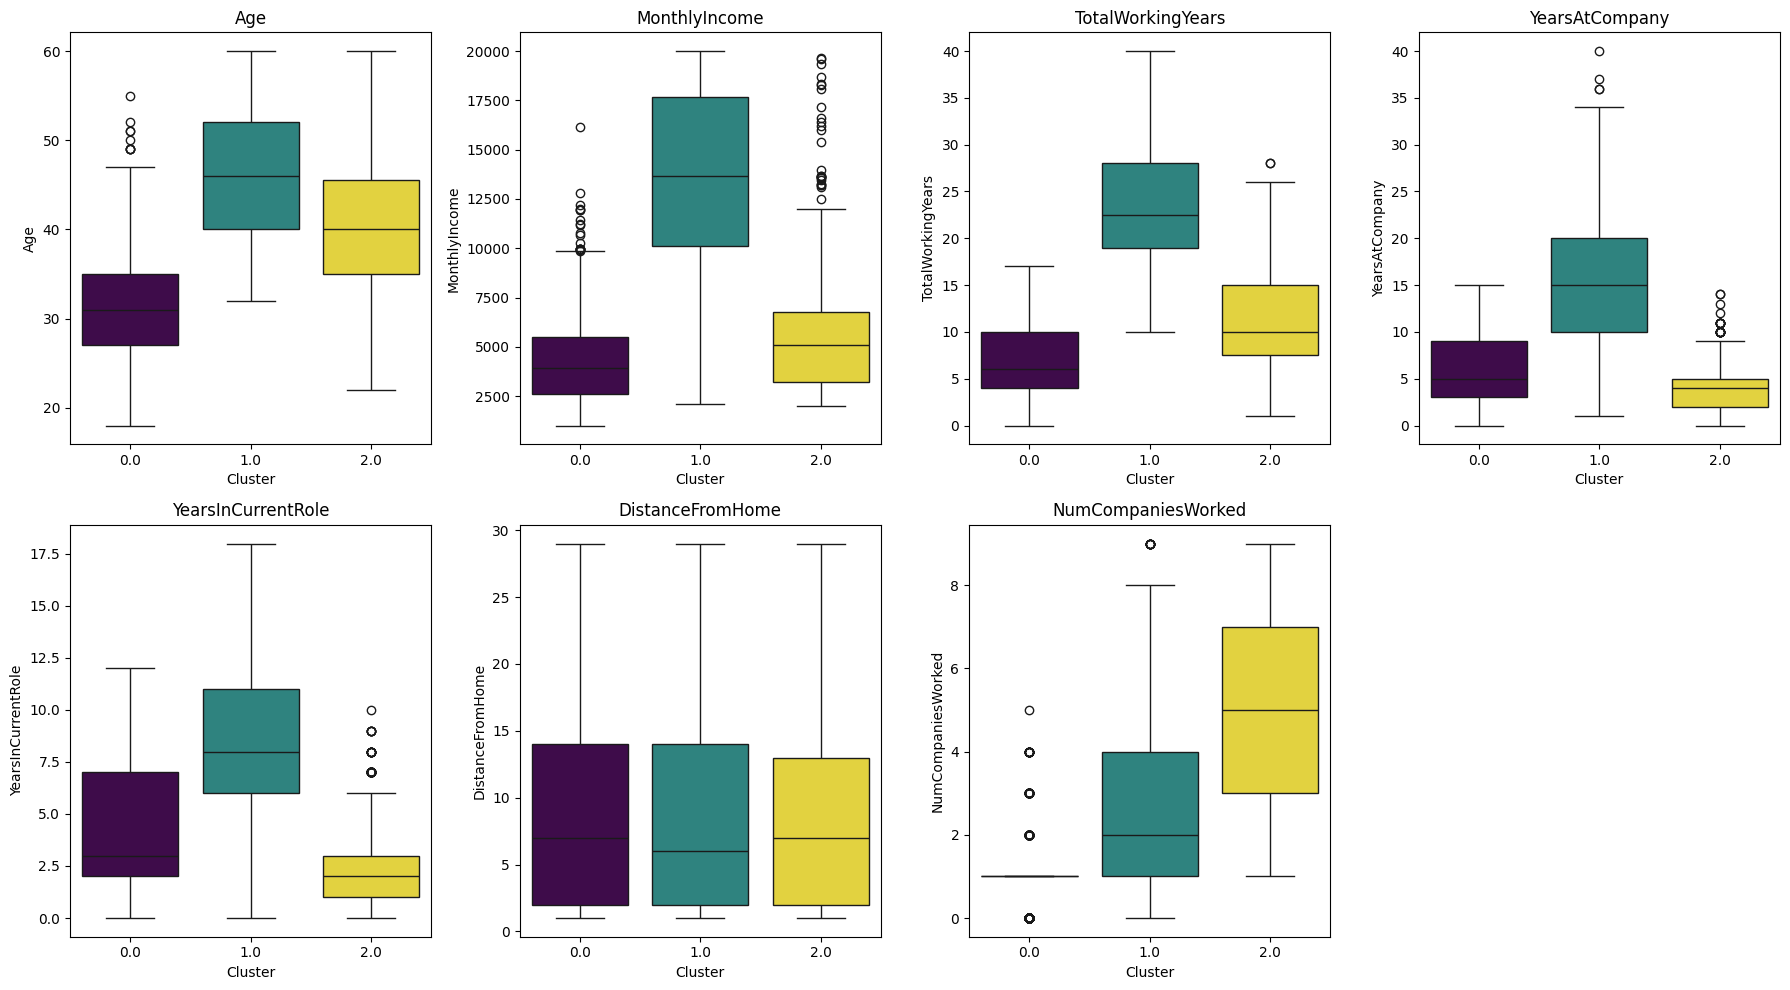

In [51]:
# Tabela Resumo dos Perfis (Média das variáveis por cluster)
summary = df.groupby('Cluster')[cols_cluster + ['Attrition_Numeric']].mean()
# Adiciona contagem de pessoas por cluster
summary['Contagem'] = df['Cluster'].value_counts()
print("\n=== PERFIL MÉDIO DOS CLUSTERS ===")
print(summary.T) 

# Boxplots para entender a influência de cada variável
plt.figure(figsize=(18, 10))
for i, col in enumerate(cols_cluster):
    plt.subplot(2, 4, i+1)
    sns.boxplot(x='Cluster', y=col, data=df, hue='Cluster', palette='viridis', legend=False)
    plt.title(col)
plt.tight_layout()
plt.savefig('influencia_variaveis.png')
plt.show()
